## Data Analysis: Initial Exploration

Before diving into analysis, it's crucial to ask meaningful questions about the data to guide our exploration. Here are some general questions we might ask about a dataset:

1.  **What does each row represent?** (e.g., a single measurement, a unique entity)
2.  **What are the key variables (columns) and what do they measure?**
3.  **What is the overall distribution of each variable?**
4.  **Are there any missing values, and if so, how should we handle them?**
5.  **What are the relationships between different variables?**
6.  **Are there any outliers or unusual observations?**

For this exercise, we will load a well-known dataset, the Iris dataset, and proceed with the exploratory steps.

In [1]:
import pandas as pd
import seaborn as sns

# Load the Iris dataset
df = sns.load_dataset('iris')

print("Dataset loaded successfully.")

Dataset loaded successfully.


### Explore Data Structure: Variables and Data Types

Now that we have loaded the dataset, let's explore its structure, including the variables present and their respective data types. This helps us understand what kind of data we are dealing with and identify any immediate data quality issues.

In [2]:
# Display basic information about the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


None

In [3]:
# Display descriptive statistics for numerical columns
display(df.describe())

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Display the first 5 rows of the DataFrame to get a glimpse of the data
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Check for Missing Values

Identifying missing values is crucial for data cleaning. We'll check if there are any `NaN` or `None` values in our dataset.

In [5]:
# Check for missing values in each column
display(df.isnull().sum())

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


### Visualize Relationships Between Variables

A pair plot is a great way to visualize pairwise relationships between variables in a dataset. By coloring the points based on the 'species' column, we can observe how the different species are distributed across the various features.

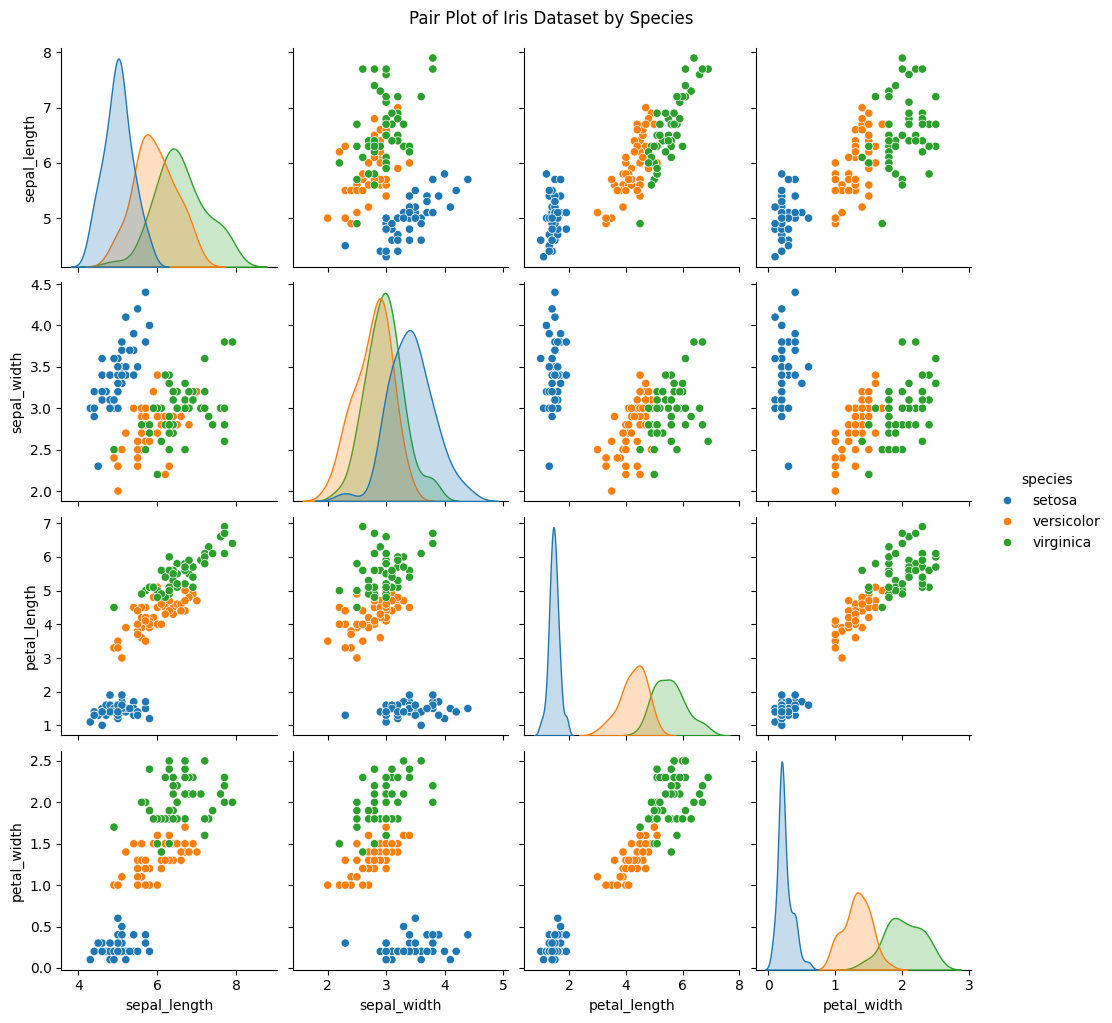

In [6]:
import matplotlib.pyplot as plt

# Create a pair plot to visualize relationships between species
sns.pairplot(df, hue='species')
plt.suptitle('Pair Plot of Iris Dataset by Species', y=1.02) # Add a title above the plots
plt.show()

### Correlation Analysis

To understand the linear relationships between numerical variables, we can compute the correlation matrix. A heatmap is an excellent way to visualize this matrix, where different colors indicate the strength and direction of the correlation.

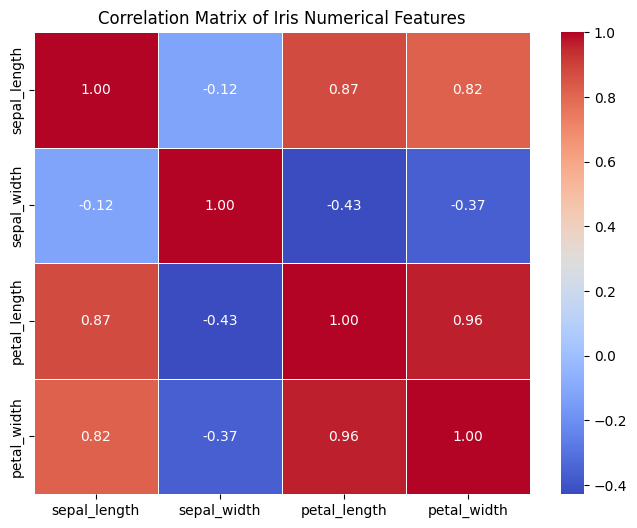

In [7]:
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical features
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Iris Numerical Features')
plt.show()

### Distribution of Individual Features

Understanding the distribution of each feature is a fundamental part of EDA. Histograms are great for numerical data to show the frequency of values, while count plots are suitable for categorical data.

In [ ]:
import matplotlib.pyplot as plt

# Plot histograms for numerical features to see their distributions
df.hist(figsize=(10, 8))
plt.suptitle('Histograms of Iris Numerical Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

### Outlier Detection and Feature Distribution by Species

Box plots are excellent for visualizing the distribution of numerical data and identifying potential outliers. By creating box plots for each numerical feature, grouped by 'species', we can observe how each species' measurements vary and if there are any values that fall significantly outside the typical range.

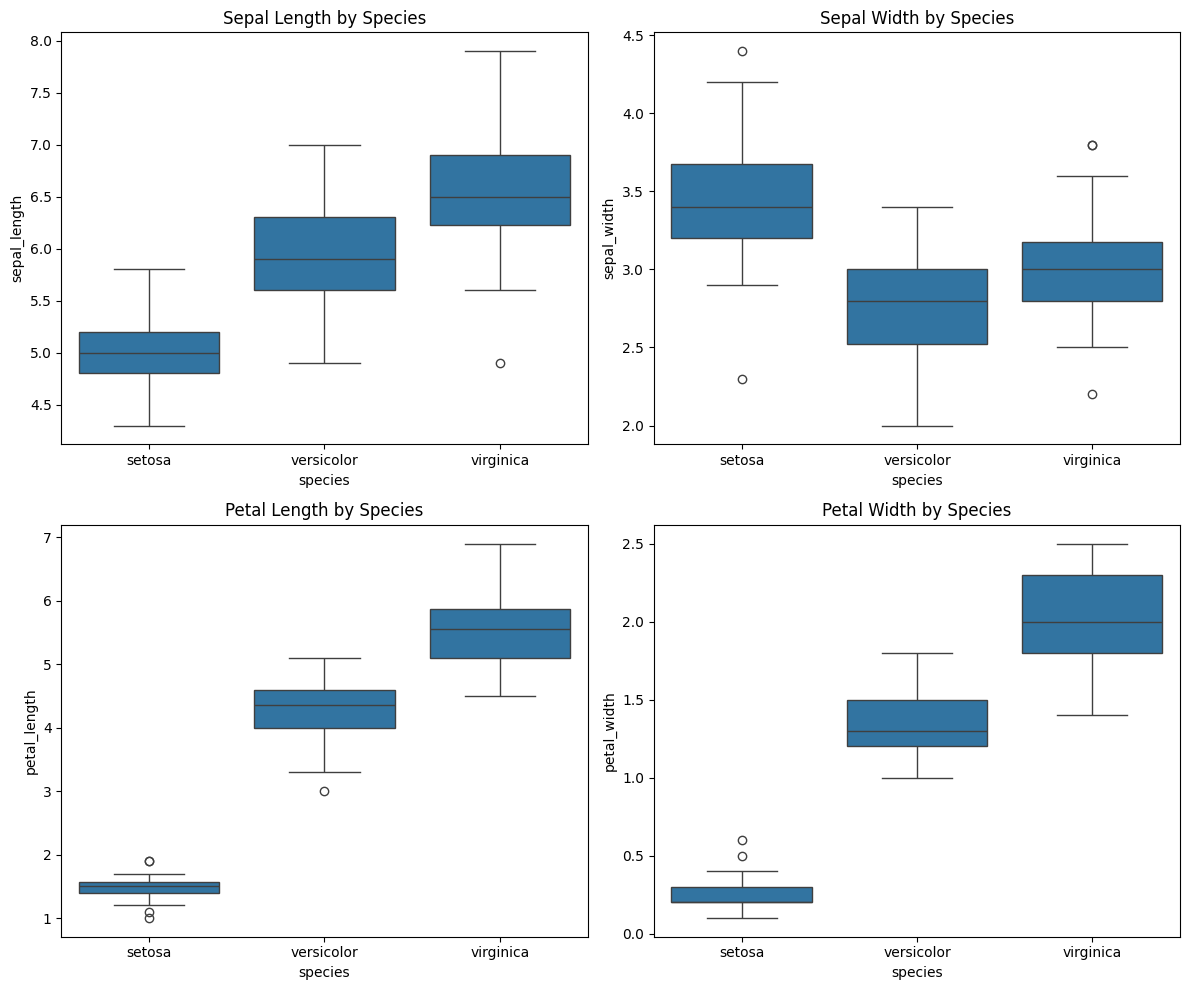

In [8]:
import matplotlib.pyplot as plt

# Create box plots for each numerical feature, grouped by species
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='species', y='sepal_length', data=df)
plt.title('Sepal Length by Species')

plt.subplot(2, 2, 2)
sns.boxplot(x='species', y='sepal_width', data=df)
plt.title('Sepal Width by Species')

plt.subplot(2, 2, 3)
sns.boxplot(x='species', y='petal_length', data=df)
plt.title('Petal Length by Species')

plt.subplot(2, 2, 4)
sns.boxplot(x='species', y='petal_width', data=df)
plt.title('Petal Width by Species')

plt.tight_layout()
plt.show()

### Distribution of Categorical Features

For categorical variables, a count plot helps us understand the frequency of each category.

/tmp/ipykernel_3611/3697648688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='viridis')


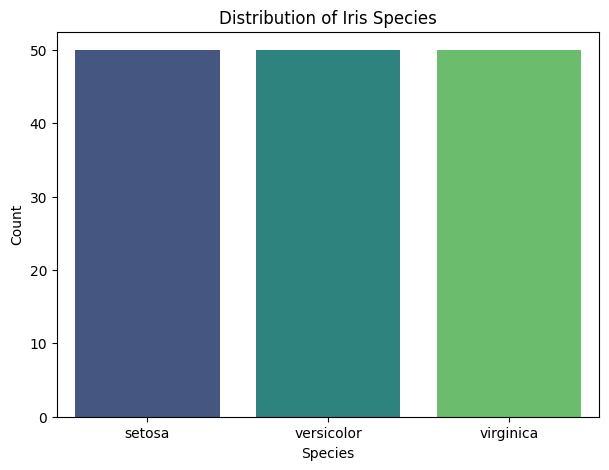

In [9]:
import matplotlib.pyplot as plt

# Create a count plot for the 'species' column
plt.figure(figsize=(7, 5))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

### Statistical Hypothesis Testing: ANOVA

To formally test for differences between the means of groups (our species) on a continuous dependent variable (our features), we can use Analysis of Variance (ANOVA). A one-way ANOVA will help us determine if there are any statistically significant differences between the means of three or more independent groups. The null hypothesis ($H_0$) is that the means of the groups are equal, and the alternative hypothesis ($H_1$) is that at least one group mean is different from the others.

In [10]:
from scipy import stats

# Perform ANOVA for sepal_length across species
setosa_sepal_length = df[df['species'] == 'setosa']['sepal_length']
versicolor_sepal_length = df[df['species'] == 'versicolor']['sepal_length']
virginica_sepal_length = df[df['species'] == 'virginica']['sepal_length']

f_statistic_sl, p_value_sl = stats.f_oneway(setosa_sepal_length, versicolor_sepal_length, virginica_sepal_length)

print(f"ANOVA for Sepal Length: F-statistic = {f_statistic_sl:.2f}, P-value = {p_value_sl:.3e}")

ANOVA for Sepal Length: F-statistic = 119.26, P-value = 1.670e-31


In [11]:
# Perform ANOVA for sepal_width across species
setosa_sepal_width = df[df['species'] == 'setosa']['sepal_width']
versicolor_sepal_width = df[df['species'] == 'versicolor']['sepal_width']
virginica_sepal_width = df[df['species'] == 'virginica']['sepal_width']

f_statistic_sw, p_value_sw = stats.f_oneway(setosa_sepal_width, versicolor_sepal_width, virginica_sepal_width)

print(f"ANOVA for Sepal Width: F-statistic = {f_statistic_sw:.2f}, P-value = {p_value_sw:.3e}")

ANOVA for Sepal Width: F-statistic = 49.16, P-value = 4.492e-17


In [12]:
# Perform ANOVA for petal_length across species
setosa_petal_length = df[df['species'] == 'setosa']['petal_length']
versicolor_petal_length = df[df['species'] == 'versicolor']['petal_length']
virginica_petal_length = df[df['species'] == 'virginica']['petal_length']

f_statistic_pl, p_value_pl = stats.f_oneway(setosa_petal_length, versicolor_petal_length, virginica_petal_length)

print(f"ANOVA for Petal Length: F-statistic = {f_statistic_pl:.2f}, P-value = {p_value_pl:.3e}")

ANOVA for Petal Length: F-statistic = 1180.16, P-value = 2.857e-91


In [13]:
# Perform ANOVA for petal_width across species
setosa_petal_width = df[df['species'] == 'setosa']['petal_width']
versicolor_petal_width = df[df['species'] == 'versicolor']['petal_width']
virginica_petal_width = df[df['species'] == 'virginica']['petal_width']

f_statistic_pw, p_value_pw = stats.f_oneway(setosa_petal_width, versicolor_petal_width, virginica_petal_width)

print(f"ANOVA for Petal Width: F-statistic = {f_statistic_pw:.2f}, P-value = {p_value_pw:.3e}")

ANOVA for Petal Width: F-statistic = 960.01, P-value = 4.169e-85


### Interpretation of ANOVA Results

For a significance level (alpha) typically set at 0.05:

*   If the p-value is less than alpha, we reject the null hypothesis, indicating that there is a statistically significant difference between the means of at least two of the species for that feature.
*   If the p-value is greater than alpha, we fail to reject the null hypothesis, meaning there is no statistically significant difference between the means of the species for that feature.

From the results above, we can observe that for 'sepal_length', 'petal_length', and 'petal_width', the p-values are extremely small (much less than 0.05), suggesting significant differences in these features across the Iris species. For 'sepal_width', while the p-value is still very small, it's slightly larger than the others, but still well below 0.05, indicating a significant difference as well. This confirms that the different species of Iris have distinct morphological characteristics.